# 02-clonotype-analysis

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import gzip
import shutil
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")
LN5 = DATA / "LN5"
LT5 = DATA / "LT5"

Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def extract_file(path: Path) -> Path:
  extracted = Path(str(path).partition(".gz")[0])

  with gzip.open(path, 'rb') as f_in:
    with open(extracted, 'wb') as f_out:
      shutil.copyfileobj(f_in, f_out)

  return extracted

def extract_mtx_data(dir: Path, prefix: str):
  extract_file(dir / f"{prefix}barcodes.tsv.gz")
  extract_file(dir / f"{prefix}genes.tsv.gz")
  extract_file(dir / f"{prefix}matrix.mtx.gz")

In [3]:
def read_sample(dir: Path, prefix: str) -> mu.MuData:
  extract_mtx_data(dir, prefix)

  adata = sc.read_10x_mtx(dir, prefix=prefix)
  adata.var_names_make_unique()
  adata_tcr = ir.io.read_10x_vdj(dir / f"{prefix}filtered_contig_annotations.csv.gz")

  mdata = mu.MuData({'gex': adata, 'airr': adata_tcr})
  mdata['gex'].obs['sample'] = str(dir)
  mdata.update()

  return mdata


In [4]:
ln5 = read_sample(LN5, "GSM4143664_SAM24360810-ln5.")
lt5 = read_sample(LT5, "GSM4143663_SAM24360809-lt5.")

In [5]:
gex  = ad.concat(
  {'lt5': lt5['gex'], 'ln5': ln5['gex']},
  label='sample_id',
  index_unique='-',
  join='outer',
)

airr = ad.concat(
  {'lt5': lt5['airr'], 'ln5': ln5['airr']},
  label='sample_id',
  index_unique='-',
  join='outer',
)

mdata = mu.MuData({'gex': gex, 'airr': airr})
mdata.update()
mdata

MuData object with n_obs × n_vars = 12932 × 30727
  2 modalities
    gex:	11008 × 30727
      obs:	'sample', 'sample_id'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [6]:
sc.pp.filter_genes(mdata["gex"], min_cells=10)
sc.pp.filter_cells(mdata["gex"], min_genes=100)
mdata

MuData object with n_obs × n_vars = 12932 × 30727
  2 modalities
    gex:	11008 × 15068
      obs:	'sample', 'sample_id', 'n_genes'
      var:	'n_cells'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [7]:
sc.pp.normalize_per_cell(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])
mdata.update()
mdata

MuData object with n_obs × n_vars = 12932 × 15068
  2 modalities
    gex:	11008 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [8]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [9]:
mdata

MuData object with n_obs × n_vars = 12932 × 15068
  2 modalities
    gex:	11008 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	7442 × 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

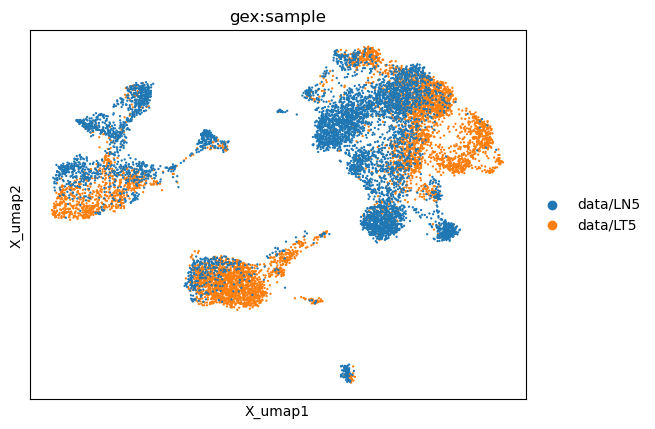

In [10]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["gex:sample"],
  ncols=3,
  wspace=0.7,
)

In [11]:
cells_multiple_tcr = np.sum(mdata.obs['airr:chain_pairing'].isin(["extra VJ", "extra VDJ", "two full chains", "multichain"])) / mdata['airr'].n_obs

print(f"Fraction of cells with extra chains: {cells_multiple_tcr}")

Fraction of cells with extra chains: 0.06476753560870734


In [12]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ", "multichain"]))

In [13]:
mdata

MuData object with n_obs × n_vars = 10624 × 15068
  2 modalities
    gex:	9408 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'gex:sample_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	5134 × 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

In [31]:
obs = mdata['airr'].obs
n_cells_single_pair = int(obs[obs['chain_pairing'] == 'single pair'].shape[0])

n_cells_no_ir = int(obs['chain_pairing'].isin(['no IR']).sum())

print(f"Number of cells with single chain pair: {n_cells_single_pair}")
print(f"Number of cells with no IR: {n_cells_no_ir}")

Number of cells with single chain pair: 4406
Number of cells with no IR: 267


In [15]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.tl.clonotype_network(mdata, min_cells=5)
mdata

MuData object with n_obs × n_vars = 10624 × 15068
  2 modalities
    gex:	9408 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'gex:sample_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	5134 × 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

In [16]:
ir.pp.ir_dist(
  mdata,
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
  # base_matrix="tcrblosum",
)

In [17]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

In [18]:
ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

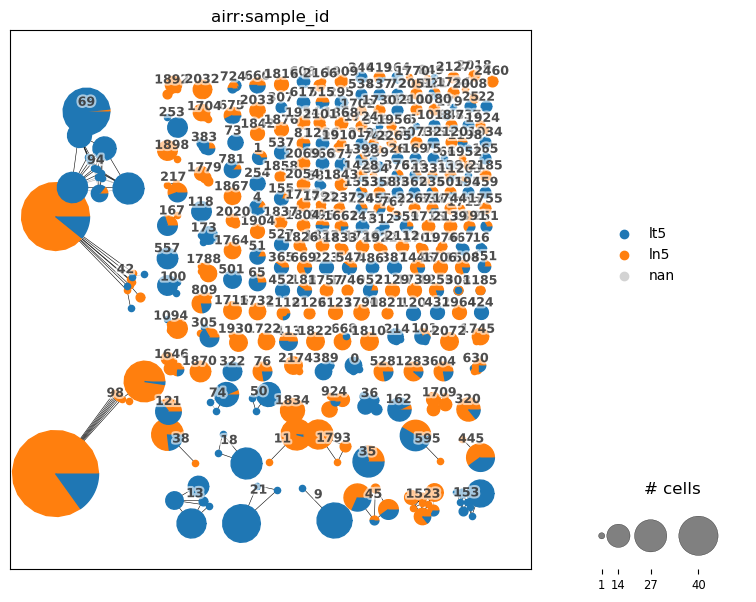

In [19]:
_ = ir.pl.clonotype_network(mdata, color="airr:sample_id", base_size=20, label_fontsize=9, panel_size=(7, 7))

In [20]:
largest_network = int(mdata.obs['airr:cc_aa_tcrdist_size'].max())

print(f"Largest clonotype network: {largest_network}")

Largest clonotype network: 243


In [21]:
ir.tl.clonal_expansion(mdata)
mdata

MuData object with n_obs × n_vars = 10624 × 15068
  2 modalities
    gex:	9408 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'gex:sample_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	5134 × 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

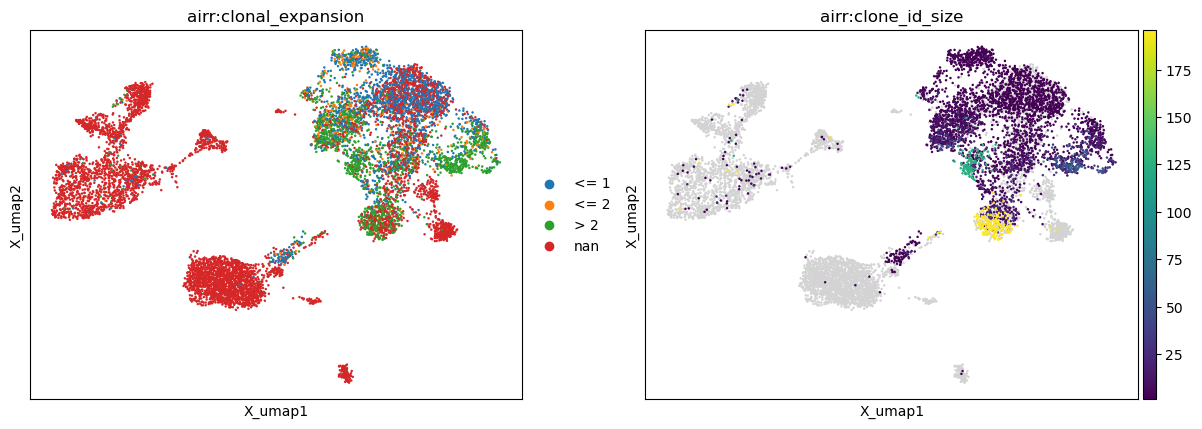

In [22]:
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"])

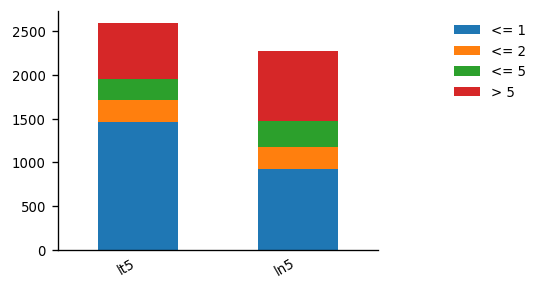

In [23]:
_ = ir.pl.clonal_expansion(mdata, target_col="clone_id", groupby="airr:sample_id", breakpoints=(1, 2, 5), normalize=False)

In [24]:
diversity = ir.tl.alpha_diversity(mdata, "airr:sample_id", inplace=False)

ln5_alpha_diversity = diversity.loc['ln5'].item()

print(f"LN5 alpha-diversity: {ln5_alpha_diversity}")

LN5 alpha-diversity: 0.8937593362265597


In [25]:
ir.tl.clonotype_convergence(mdata, key_coarse="cc_aa_tcrdist", key_fine="clone_id")
mdata

MuData object with n_obs × n_vars = 10624 × 15068
  2 modalities
    gex:	9408 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'gex:sample_colors', 'airr:clonal_expansion_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	5134 × 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion', 'is_convergent'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

In [29]:
obs = mdata['airr'].obs
obs = obs[obs['is_convergent'] == 'convergent']

convergent_clonotypes = int(obs['clone_id'].nunique())

print(f"Convergent clonotypes: {convergent_clonotypes}")

Convergent clonotypes: 202


In [32]:
output = {
  "cells_multiple_tcr": cells_multiple_tcr,
  "n_cells_single_pair": n_cells_single_pair,
  "n_cells_no_ir": n_cells_no_ir,
  "largest_network": largest_network,
  "more_clonotypes": "LT5",
  "more_expanded": "LN5",
  "more_between_2_5": "LN5",
  "ln5_alpha_diversity": ln5_alpha_diversity,
  "convergent_clonotypes": convergent_clonotypes
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "cells_multiple_tcr": 0.06476753560870734,
  "n_cells_single_pair": 4406,
  "n_cells_no_ir": 267,
  "largest_network": 243,
  "more_clonotypes": "LT5",
  "more_expanded": "LN5",
  "more_between_2_5": "LN5",
  "ln5_alpha_diversity": 0.8937593362265597,
  "convergent_clonotypes": 202
}
